# 02 · Reversible transformer, same fixed batch size

The reversible stack keeps **only the final state**. In backward, each layer evaluates its block **once** with grad. The detached output reconstructs the layer's input, and the same graph gives the vector-Jacobian product (`Stepper.backward_step` in `revllm/model.py`). The overhead is therefore one extra block forward per layer.

| variant (key) | update | inverse |
|---|---|---|
| `hamiltonian` (Hamiltonian, a = b = 1; same as RevNet/Reformer coupling) | p' = p + Attn(q); q' = q + MLP(p') | q = q' − MLP(p'); p = p' − Attn(q) |
| `midpoint_a0.5_h0.25` (**midpoint(a)**, the lesson's recipe) | p₍ⱼ₊₁₎ = a·p₍ⱼ₋₁₎ + (1−a)·pⱼ + h·f(pⱼ) | p₍ⱼ₋₁₎ = (p₍ⱼ₊₁₎ − (1−a)·pⱼ − h·f(pⱼ)) / a |
| `midpoint_plain_h0.25` (plain midpoint, ablation) | p₍ⱼ₊₁₎ = p₍ⱼ₋₁₎ + 2h·f(pⱼ) | p₍ⱼ₋₁₎ = p₍ⱼ₊₁₎ − 2h·f(pⱼ) |
| `leapfrog_h1` (velocity Verlet) | v' = v + h·f(x); x' = x + h·v' | x = x' − h·v'; v = v' − h·f(x) |

Euler (`p' = p + f(p)`, the baseline) is **not** in this list. It cannot be inverted: recovering p from p' means solving p = p' − f(p), which has no closed form, so its activations have to be stored.

**Step A:** a short (5M-token) sweep over the four variants at the fixed batch size.  
**Step B:** the full 50M-token run with the variant that has the lowest validation loss.

In [1]:
# --- Colab setup: GPU runtime (Runtime > Change runtime type > T4 GPU) ---
REPO_URL = "https://github.com/gaurkhare/gaurav-eagv5-s13.git"
import os, sys, json
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/era_a13"          # data + results persist across notebooks
    if not os.path.exists("/content/repo"):
        !git clone -q {REPO_URL} /content/repo
    os.chdir("/content/repo")
else:
    WORK = os.path.abspath("..")                      # running locally from notebooks/
    os.chdir(WORK)
sys.path.insert(0, os.getcwd())
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
DATA_DIR, RESULTS = f"{WORK}/data", f"{WORK}/results"
os.makedirs(RESULTS, exist_ok=True)
!nvidia-smi --query-gpu=name,memory.total --format=csv 2>/dev/null || echo "no nvidia GPU"

Mounted at /content/drive
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
import torch, copy
from revllm import LLM, ModelConfig, TrainConfig, train, fits, get_device, VARIANTS
from revllm.train import amp_dtype
B_FIXED = json.load(open(f"{RESULTS}/batch.json"))["fixed_batch"]
dev = get_device()
dev64 = dev if dev.type == "cuda" else torch.device("cpu")   # MPS has no float64
print("fixed batch:", B_FIXED)
for k, v in VARIANTS.items():
    print(f"  {k:22s} {v}")

fixed batch: 64
  hamiltonian            {'residual': 'hamiltonian'}
  midpoint_a0.5_h0.25    {'residual': 'midpoint', 'a': 0.5, 'h': 0.25}
  midpoint_plain_h0.25   {'residual': 'midpoint', 'a': 1.0, 'h': 0.5}
  leapfrog_h1            {'residual': 'leapfrog', 'h': 1.0}


## Sanity check: reversible backprop gives the same gradients as ordinary autograd (fp64)

In [3]:
torch.manual_seed(0)
for name, kw in VARIANTS.items():
    small = ModelConfig(vocab_size=500, seq_len=64, d_model=64, n_layers=4, n_heads=4, d_ff=128, rev_backprop=False, **kw)
    ref = LLM(small).double().to(dev64); rev = copy.deepcopy(ref); rev.cfg.rev_backprop = True
    x = torch.randint(0, 500, (2, 65), device=dev64)
    ref(x[:, :-1], x[:, 1:]).backward(); rev(x[:, :-1], x[:, 1:]).backward()
    err = max((a.grad - b.grad).abs().max().item() for a, b in zip(ref.parameters(), rev.parameters()))
    print(f"{name:22s} fp64 max |grad diff| = {err:.2e}")

hamiltonian            fp64 max |grad diff| = 6.94e-18
midpoint_a0.5_h0.25    fp64 max |grad diff| = 1.39e-17
midpoint_plain_h0.25   fp64 max |grad diff| = 1.39e-17
leapfrog_h1            fp64 max |grad diff| = 7.63e-17


## Mixed-precision drift of each variant (20M model, random init)

* **recon**: invert all 8 layers and report ‖p̂₀ − p₀‖/‖p₀‖.
* **grad**: relative difference between the reversible-backprop gradient and plain autograd, both under autocast.

midpoint(a) divides by a in its inverse, so its reconstruction error should be larger than plain midpoint's.

This cell calls `backward()` *inside* the autocast region. Before the fix in `revllm/model.py: _amp_state` (`cache_enabled=False`), that pattern silently dropped every block weight's gradient in the reversible model; `tests/test_reversible.py::test_autocast_grads_present_and_close` guards it.

In [4]:
def drift(kw, B=8):
    torch.manual_seed(0)
    m = LLM(ModelConfig(**kw)).to(dev); ref = copy.deepcopy(m); ref.cfg.rev_backprop = False
    dt = amp_dtype(dev); x = torch.randint(0, 32000, (B, 513), device=dev)
    with torch.no_grad(), torch.autocast(dev.type, dtype=dt):
        p, q = m.stepper.init(m.embed(x[:, :-1])); p0 = p.clone()
        for b in m.blocks: p, q = m.stepper.step(b, p, q, m.cos, m.sin)
        for b in reversed(m.blocks): p, q = m.stepper.inverse(b, p, q, m.cos, m.sin)
    for mm in (m, ref):
        with torch.autocast(dev.type, dtype=dt): (mm(x[:, :-1], x[:, 1:]) * 1024).backward()
    g1 = torch.cat([t.grad.flatten().float() for t in ref.parameters()])
    g2 = torch.cat([t.grad.flatten().float() for t in m.parameters()])
    return ((p - p0).norm() / p0.norm()).item(), ((g1 - g2).norm() / g1.norm()).item()

DRIFT = {}
for name, kw in VARIANTS.items():
    DRIFT[name] = dict(zip(["recon_rel_err", "grad_rel_err"], drift(kw)))
    print(f"{name:22s} recon {DRIFT[name]['recon_rel_err']:.2e}   grad {DRIFT[name]['grad_rel_err']:.2%}   ({amp_dtype(dev)})")
json.dump(DRIFT, open(f"{RESULTS}/drift_init.json", "w"), indent=1)

hamiltonian            recon 1.24e-03   grad 0.37%   (torch.bfloat16)
midpoint_a0.5_h0.25    recon 1.48e-02   grad 0.36%   (torch.bfloat16)
midpoint_plain_h0.25   recon 2.10e-03   grad 0.34%   (torch.bfloat16)
leapfrog_h1            recon 2.92e-02   grad 2.98%   (torch.bfloat16)


## Peak memory at the fixed batch: plain autograd vs reversible backprop

In [5]:
mem = {}
for name, kw in {"euler": dict(residual="euler"), **VARIANTS}.items():
    for rb in ([False] if name == "euler" else [False, True]):
        ok, peak = fits(ModelConfig(rev_backprop=rb, **kw), B_FIXED)
        mem[f"{name}{' (reversible backprop)' if rb else ''}"] = peak
        print(f"{name:22s} rev_backprop={rb!s:5s}: {'%.2f GB' % peak if ok else 'OOM'}")
json.dump(mem, open(f"{RESULTS}/mem_at_fixed_batch.json", "w"), indent=1)

euler                  rev_backprop=False: 8.11 GB
hamiltonian            rev_backprop=False: 8.11 GB
hamiltonian            rev_backprop=True : 2.20 GB
midpoint_a0.5_h0.25    rev_backprop=False: 8.11 GB
midpoint_a0.5_h0.25    rev_backprop=True : 2.18 GB
midpoint_plain_h0.25   rev_backprop=False: 8.11 GB
midpoint_plain_h0.25   rev_backprop=True : 2.14 GB
leapfrog_h1            rev_backprop=False: 8.11 GB
leapfrog_h1            rev_backprop=True : 2.26 GB


## Activations saved for backward vs depth (B = 4, T = 512)

Counts the bytes autograd actually keeps for backward (saved-tensor hooks, each storage counted once), under the same autocast dtype as training. This is the table in README §2: Euler grows with depth, every reversible variant stays flat.

In [6]:
def saved_mb(cfg, B=4):
    torch.manual_seed(0); m = LLM(cfg).to(dev); x = torch.randint(0, 32000, (B, 513), device=dev)
    seen, tot = set(), 0
    def pack(t):
        nonlocal tot
        k = (t.untyped_storage().data_ptr(), t.untyped_storage().nbytes())
        if k not in seen: seen.add(k); tot += k[1]
        return t
    with torch.autograd.graph.saved_tensors_hooks(pack, lambda t: t), torch.autocast(dev.type, dtype=amp_dtype(dev)):
        loss = m(x[:, :-1], x[:, 1:])
    del loss, m
    return tot / 2**20

SAVED = {}
for L in [8, 16, 32]:
    SAVED[L] = {"euler": saved_mb(ModelConfig(residual="euler", n_layers=L)),
                **{k: saved_mb(ModelConfig(n_layers=L, **kw)) for k, kw in VARIANTS.items()}}
    print(f"L={L:2d} " + "  ".join(f"{k} {v:.0f} MB" for k, v in SAVED[L].items()))
json.dump(SAVED, open(f"{RESULTS}/saved_bytes_vs_depth.json", "w"), indent=1)

L= 8 euler 462 MB  hamiltonian 49 MB  midpoint_a0.5_h0.25 47 MB  midpoint_plain_h0.25 49 MB  leapfrog_h1 47 MB
L=16 euler 880 MB  hamiltonian 49 MB  midpoint_a0.5_h0.25 47 MB  midpoint_plain_h0.25 49 MB  leapfrog_h1 47 MB
L=32 euler 1716 MB  hamiltonian 49 MB  midpoint_a0.5_h0.25 47 MB  midpoint_plain_h0.25 49 MB  leapfrog_h1 47 MB


## Step A: variant sweep (5M tokens each)

In [7]:
sweep = {}
for name, kw in VARIANTS.items():
    cfg = TrainConfig(name=f"sweep_{name}", data_dir=DATA_DIR, out_dir=RESULTS, batch_size=B_FIXED,
                      total_tokens=5_000_000, lr=1e-3, eval_every=10, model=ModelConfig(**kw))
    sweep[name], _ = train(cfg)
for name, r in sweep.items():
    print(f"{name:22s} val {r['final_val_loss']:.4f}  {r['tokens_per_s']/1e3:.1f}k tok/s  peak {r['peak_mem_allocated_gb']:.2f} GB")
# a diverged run has NaN val loss; min() never replaces a NaN that comes first, so rank NaN as +inf
import math
score = lambda v: sweep[v]["final_val_loss"] if math.isfinite(sweep[v]["final_val_loss"]) else float("inf")
BEST = min(sweep, key=score)
assert math.isfinite(score(BEST)), "every variant diverged"
print("best variant:", BEST)

[sweep_hamiltonian] device=cuda amp=torch.bfloat16 params=20.16M residual=hamiltonian (reversible backprop) B=64 T=512 steps=152 tokens=5.0M lr=0.001
  eval @ 10: val_loss 7.8777
  eval @ 20: val_loss 7.3519
  eval @ 30: val_loss 7.2131
  eval @ 40: val_loss 7.0302
  eval @ 50: val_loss 6.8979
  eval @ 60: val_loss 6.7880
  eval @ 70: val_loss 6.6898
  eval @ 80: val_loss 6.5837
  eval @ 90: val_loss 6.5186
step   100/152 loss 6.4630 (ema 7.1232) lr 3.53e-04 gnorm 0.40 8.4k tok/s peak 7.05 GB
  eval @ 100: val_loss 6.4595
  eval @ 110: val_loss 6.4173
  eval @ 120: val_loss 6.3842
  eval @ 130: val_loss 6.3573
  eval @ 140: val_loss 6.3363
  eval @ 150: val_loss 6.3193
step   152/152 loss 6.2928 (ema 6.9103) lr 1.00e-04 gnorm 0.39 8.4k tok/s peak 7.05 GB
  eval @ 152: val_loss 6.3162
[sweep_hamiltonian] final train 6.2928 | val 6.3162 | 8.4k tok/s | peak alloc 7.05 GB (reserved 7.97) | 13.4 min
[sweep_midpoint_a0.5_h0.25] device=cuda amp=torch.bfloat16 params=20.16M residual=midpoint (

## Step B: full 50M-token run with the best variant, same batch as the baseline

In [8]:
# BEST = "midpoint_a0.5_h0.25"   # uncomment to override the sweep result
json.dump({"best_variant": BEST, "model_kwargs": VARIANTS[BEST]}, open(f"{RESULTS}/variant.json", "w"))
cfg = TrainConfig(name="reversible", data_dir=DATA_DIR, out_dir=RESULTS, batch_size=B_FIXED,
                  total_tokens=50_000_000, lr=1e-3, model=ModelConfig(**VARIANTS[BEST]))
res, model = train(cfg)

[reversible] device=cuda amp=torch.bfloat16 params=20.16M residual=leapfrog (reversible backprop) B=64 T=512 steps=1525 tokens=50.0M lr=0.001
step   100/1525 loss 6.0437 (ema 7.4970) lr 9.95e-04 gnorm 0.46 8.3k tok/s peak 7.14 GB
step   200/1525 loss 5.3169 (ema 6.7064) lr 9.72e-04 gnorm 0.44 8.3k tok/s peak 7.14 GB
  eval @ 250: val_loss 5.1826
step   300/1525 loss 5.0251 (ema 6.0668) lr 9.30e-04 gnorm 0.50 8.3k tok/s peak 7.14 GB
step   400/1525 loss 4.8270 (ema 5.5827) lr 8.71e-04 gnorm 0.49 8.3k tok/s peak 7.14 GB
step   500/1525 loss 4.6507 (ema 5.2234) lr 7.99e-04 gnorm 0.45 8.3k tok/s peak 7.14 GB
  eval @ 500: val_loss 4.6751
step   600/1525 loss 4.5071 (ema 4.9626) lr 7.15e-04 gnorm 0.45 8.3k tok/s peak 7.14 GB
step   700/1525 loss 4.5225 (ema 4.8033) lr 6.24e-04 gnorm 0.46 8.2k tok/s peak 7.14 GB
  eval @ 750: val_loss 4.4371
step   800/1525 loss 4.4874 (ema 4.6583) lr 5.30e-04 gnorm 0.50 8.3k tok/s peak 7.14 GB
step   900/1525 loss 4.3582 (ema 4.5449) lr 4.36e-04 gnorm 0.48 

## Reconstruction drift of the *trained* model

In [9]:
dt = amp_dtype(dev)
x = torch.randint(0, 32000, (4, 512), device=dev)
with torch.no_grad(), torch.autocast(dev.type, dtype=dt):
    p, q = model.stepper.init(model.embed(x)); p0 = p.clone()
    for blk in model.blocks: p, q = model.stepper.step(blk, p, q, model.cos, model.sin)
    for blk in reversed(model.blocks): p, q = model.stepper.inverse(blk, p, q, model.cos, model.sin)
rel = ((p - p0).norm() / p0.norm()).item()
print(f"{BEST}: relative reconstruction error after {len(model.blocks)} layers ({dt}), trained weights: {rel:.2e}")
json.dump({"variant": BEST, "recon_rel_err": rel, "dtype": str(dt)}, open(f"{RESULTS}/drift_trained.json", "w"))

leapfrog_h1: relative reconstruction error after 8 layers (torch.bfloat16), trained weights: 2.14e-01


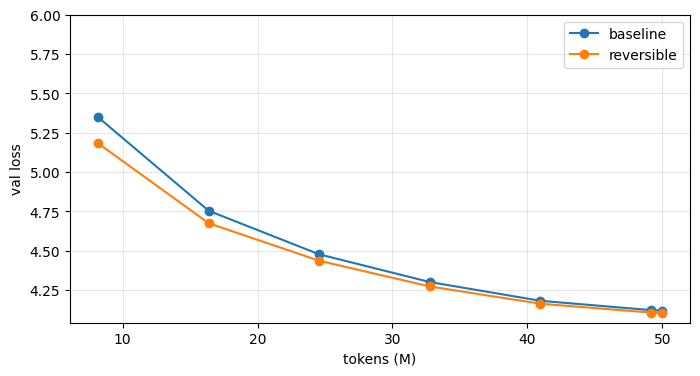

In [10]:
import matplotlib.pyplot as plt
base = json.load(open(f"{RESULTS}/baseline.json"))
plt.figure(figsize=(8, 4))
for r in [base, res]:
    plt.plot([e["tokens"]/1e6 for e in r["evals"]], [e["val_loss"] for e in r["evals"]], "o-", label=r["name"])
plt.xlabel("tokens (M)"); plt.ylabel("val loss"); plt.ylim(top=6); plt.legend(); plt.grid(alpha=.3); plt.show()